# Battery Degradation

In reality, batteries **degrade**. Aggressive charging/discharging and low/high state of charges wears them out, reducing capacity over time. This creates a more interesting problem suited for RL: minimize short-term electricity cost while preserving battery health to be able to reduce costs later on.

- **LP/MPC** (in their current implementation) optimize for cost only. They have no model of degradation and will aggressively cycle the battery.
- **RL** can learn from the reward signal. By shaping the reward signal, we can design the RL problem in a way that the agent can discover gentler strategies that balance cost savings with battery longevity.

### Degradation model

Our environment models two sources of battery damage:
1. **Aggressive cycling**: Charging or discharging above 70% of max power causes adds damage
2. **Extreme SoC**: Keeping the battery below 20% or above 80% of capacity stresses the cells.

Each damage event reduces `health` by a `damage_rate`. Health starts at 1.0 and can't drop below 0.3. As health decreases, the **effective capacity** shrinks (`capacity = max_capacity * health`), making the battery less useful over time.

The reward now includes: `reward = -grid_cost - health_weight * health_damage`

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "02_solutions"))
sys.path.insert(0, str(project_root / "01_workshop"))

import numpy as np
import matplotlib.pyplot as plt
from baselines import make_heuristic_policy, make_lp_policy, make_mpc_policy
from utils import run_episode, plot_episode, compute_energy_cost, LiveEvalCallback

# If you want to test your environment, set USE_SOLUTION to False and import the environment from the envs folder.
USE_SOLUTION = True
if USE_SOLUTION:
    from battery_env_solution import BatteryStorageEnv
else: 
    from envs.battery_env import BatteryStorageEnv

## 1. Environment Setup

In [2]:
# === Configuration ===
EPISODE_LENGTH = 730           # 1 month episodes (730 hours)
FORECAST_HORIZON = 4           # length of noisy forecast (in hours) 
TRAIN_FRACTION = 0.8

# Battery properties
CAPACITY = 10.0              # kWh
MAX_CHARGE_RATE = 2.5       # kW

# Degradation is ON — this is the key difference from notebook 03
ENABLE_DEGRADATION = True

# === Create environment ===
env = BatteryStorageEnv(
    episode_length=EPISODE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    split="train",
    train_fraction=TRAIN_FRACTION,
    capacity=CAPACITY,
    max_charge_rate=MAX_CHARGE_RATE,
    enable_degradation=ENABLE_DEGRADATION
)

print("=== Battery Storage Environment (with Degradation) ===")
print(f"Capacity:        {env.capacity} kWh")
print(f"Max charge rate: {env.max_charge_rate} kW")
print(f"Episode length:  {env.episode_length} steps")
print(f"Degradation:     {env.enable_degradation}")
print(f"\nDegradation parameters:")
print(f"  Damage rate:         {env.damage_rate} per event")
print(f"  Aggressive threshold: {env.aggresive_charge_threshold * 100:.0f}% of max charge rate ({env.aggresive_charge_threshold * env.max_charge_rate:.2f} kW)")
print(f"  SoC stress zone:     below {env.soc_low_threshold * 100:.0f}% or above {env.soc_high_threshold * 100:.0f}% of capacity")
print(f"  Min health:          {env.min_health}")
print(f"  Health weight:       {env.health_weight} (reward penalty per unit of health lost)")

=== Battery Storage Environment (with Degradation) ===
Capacity:        10.0 kWh
Max charge rate: 2.5 kW
Episode length:  730 steps
Degradation:     True

Degradation parameters:
  Damage rate:         0.002 per event
  Aggressive threshold: 70% of max charge rate (1.75 kW)
  SoC stress zone:     below 20% or above 80% of capacity
  Min health:          0.3
  Health weight:       100 (reward penalty per unit of health lost)


## 2. Baseline Comparison (with Degradation)

Let's see how the same baselines from notebook 03 perform now that degradation is active.

**Important:** The baselines (Heuristic, MPC, LP) don't know about degradation. They optimize purely for electricity cost. The environment applies degradation to the battery, but the baselines can't see or react to it. Only the RL agent's **reward** includes the health penalty, so only RL has an incentive to be gentle.

In [3]:
first_episode_in_split, last_episode_in_split = env._available_episodes
baseline_cost = np.mean(np.sum(env.prices[first_episode_in_split:last_episode_in_split] * env.loads[first_episode_in_split:last_episode_in_split], axis=1))

policies = {
    "Random":      "random",
    "Heuristic":   make_heuristic_policy(env),
    "MPC (H=4)":   make_mpc_policy(env, horizon=FORECAST_HORIZON),
    "LP (optimal)": make_lp_policy(env),
}

print(f"Baseline cost (no battery): {baseline_cost:.2f} \u20ac")
print()
print("Policy Comparison (10 episodes each)")
print("=" * 78)
print(f"{'Policy':<18} {'Avg Cost (\u20ac)':>15} {'Savings (\u20ac)':>15} {'Savings (%)':>12} {'Final Health':>14}")
print("-" * 78)

for name, policy in policies.items():
    episode_costs = []
    episode_healths = []
    for seed in range(10):
        data, reward = run_episode(env, policy=policy, seed=seed)
        energy_cost = compute_energy_cost(data)
        episode_costs.append(energy_cost)
    cost = np.mean(episode_costs)
    savings = baseline_cost - cost
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {cost:>11.1f} ± {np.std(episode_costs):.1f} {savings:>+11.1f} {pct:>+11.1f}%")

Baseline cost (no battery): 156.78 €

Policy Comparison (10 episodes each)
Policy                Avg Cost (€)     Savings (€)  Savings (%)   Final Health
------------------------------------------------------------------------------
Random                   182.6 ± 3.6       -25.8       -16.5%
Heuristic                145.5 ± 2.5       +11.3        +7.2%
MPC (H=4)                118.4 ± 2.3       +38.3       +24.5%
LP (optimal)             106.9 ± 2.6       +49.9       +31.8%


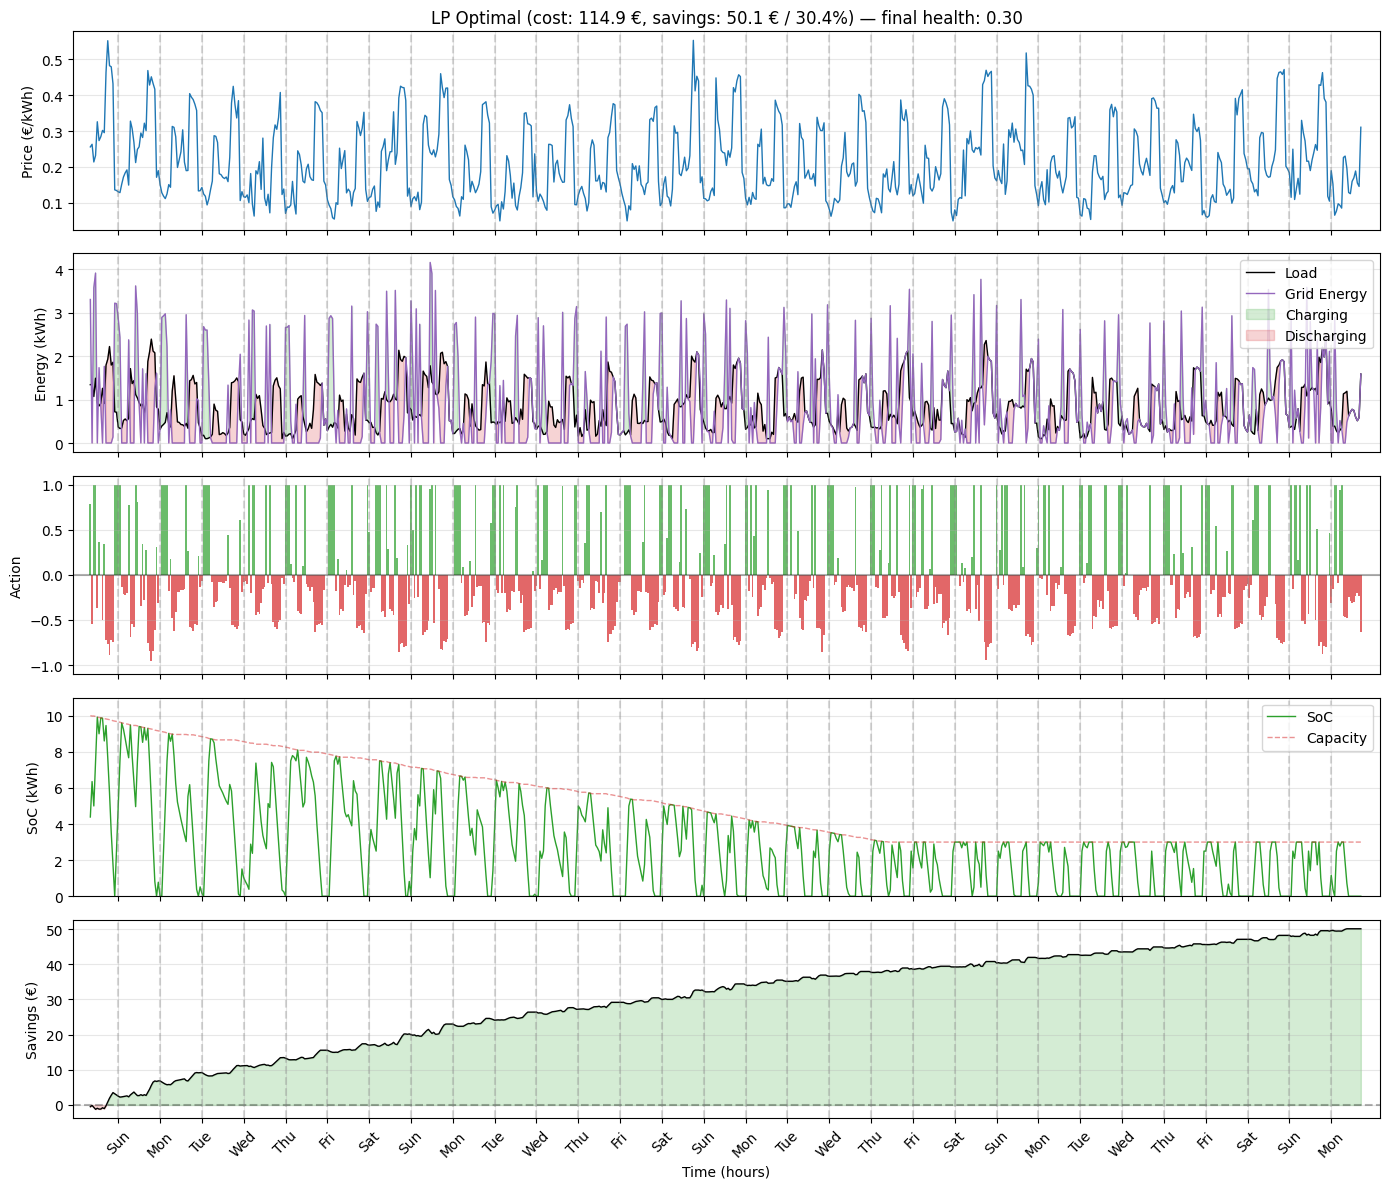

In [4]:
lp_policy = make_lp_policy(env)
data, _ = run_episode(env, policy=lp_policy, seed=42)
cost = compute_energy_cost(data)
no_battery_cost = float(np.sum(np.array(data["price"]) * np.array(data["load"])))
savings = no_battery_cost - cost

fig = plot_episode(data, f"LP Optimal (cost: {cost:.1f} \u20ac, savings: {savings:.1f} \u20ac / {100*savings/no_battery_cost:.1f}%) — final health: {data['health'][-1]:.2f}", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

## 4. Train PPO (with Degradation Awareness)

Now let's train PPO on the degradation-enabled environment. The key difference from notebook 03:
- The reward now penalizes health damage: `reward = -grid_cost - 100 * health_damage`
- The observation includes battery `health`, so the agent can see the battery wearing out
- The agent must learn to **balance** cost savings with battery preservation

Can PPO discover a gentler strategy that keeps the battery healthy while still saving money?

In [5]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

def make_train_env():
    return BatteryStorageEnv(
        split="train",
        episode_length=EPISODE_LENGTH,
        forecast_horizon=FORECAST_HORIZON,
        train_fraction=TRAIN_FRACTION,
        capacity=CAPACITY,
        max_charge_rate=MAX_CHARGE_RATE,
        enable_degradation=ENABLE_DEGRADATION,
    )

train_env = make_vec_env(make_train_env, n_envs=4)

eval_env = BatteryStorageEnv(
    split="eval",
    episode_length=EPISODE_LENGTH,
    forecast_horizon=FORECAST_HORIZON,
    train_fraction=TRAIN_FRACTION,
    capacity=CAPACITY,
    max_charge_rate=MAX_CHARGE_RATE,
    enable_degradation=ENABLE_DEGRADATION,
)

print(f"Train episodes: {env._available_episodes}")
print(f"Eval episodes:  {eval_env._available_episodes}")

model = PPO("MlpPolicy", train_env, verbose=0)

Train episodes: (0, 96)
Eval episodes:  (96, 120)


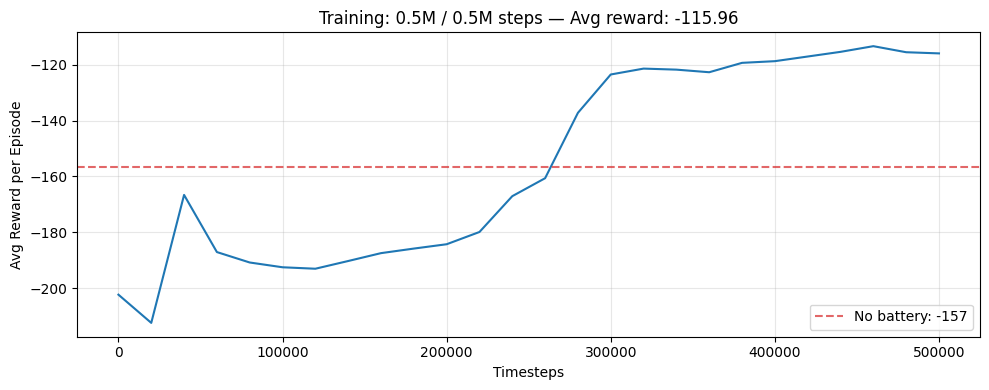

Training complete!


In [6]:
TOTAL_TIMESTEPS = int(5e5)

first_episode_in_split, last_episode_in_split = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[first_episode_in_split:last_episode_in_split] * eval_env.loads[first_episode_in_split:last_episode_in_split], axis=1))

callback = LiveEvalCallback(
    eval_env=eval_env,
    eval_freq=20_000,
    baseline_cost=baseline_cost,
)

print(f"Training PPO for {TOTAL_TIMESTEPS/1e3:.0f}k steps...")
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
print("Training complete!")

Visualize Trained PPO

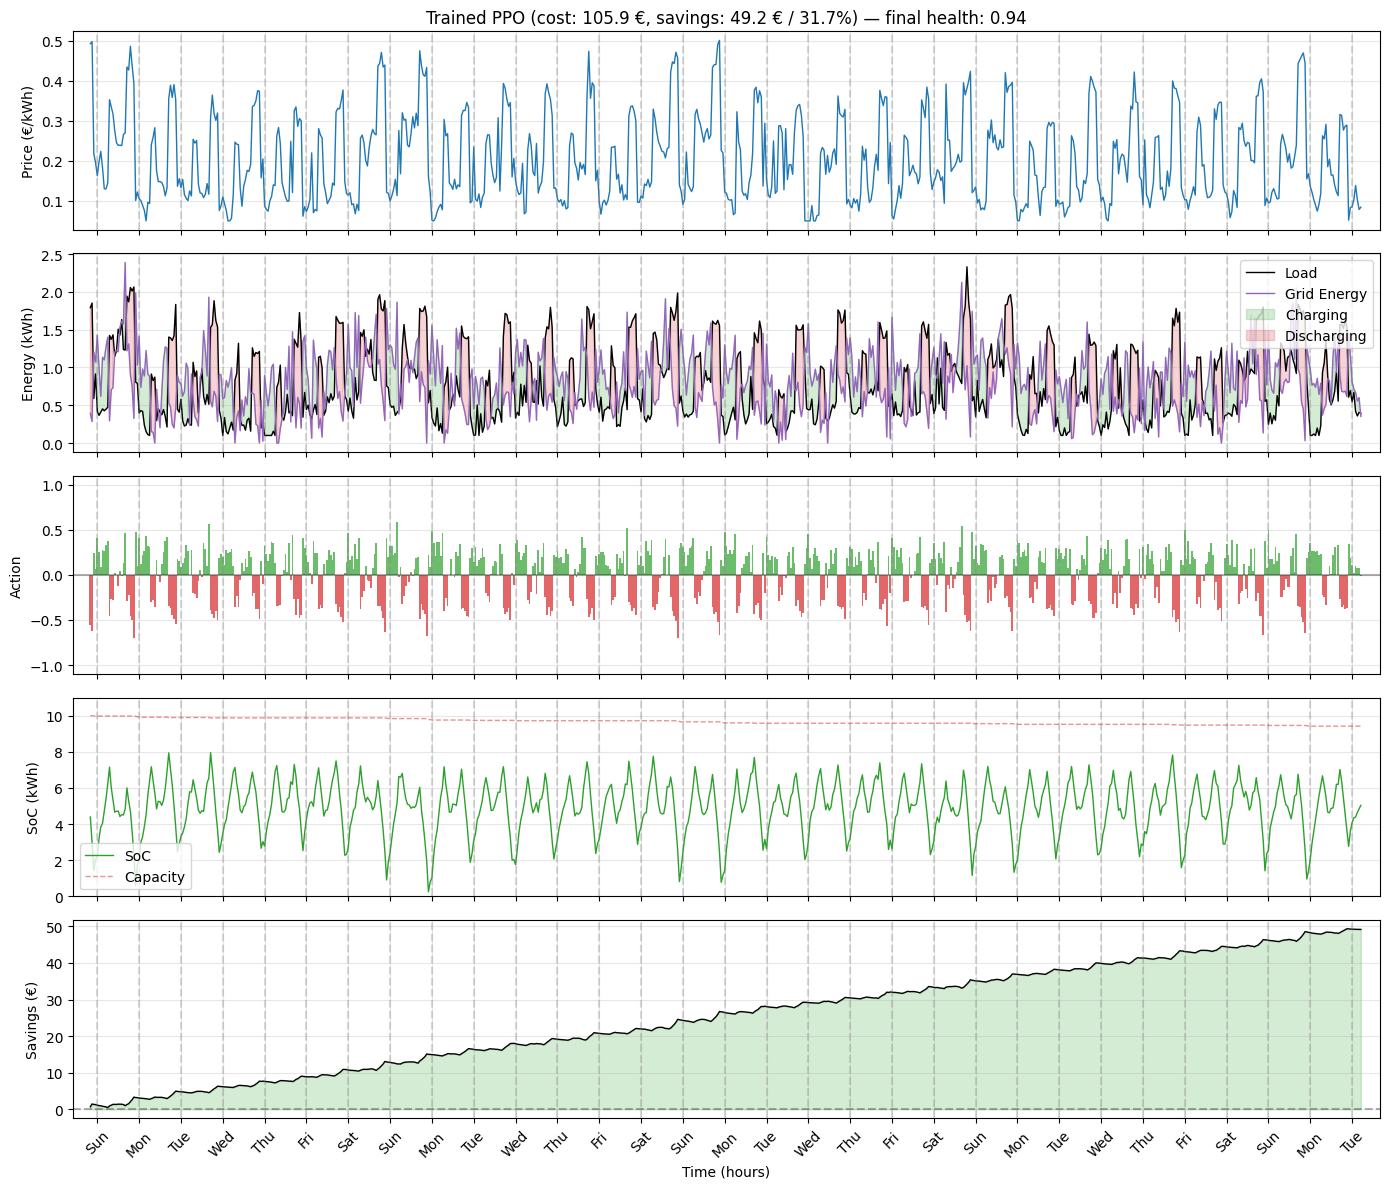

In [7]:
ppo_policy = lambda obs: model.predict(obs, deterministic=True)[0]
data_ppo, reward_ppo = run_episode(eval_env, policy=ppo_policy, seed=42)
cost_ppo = compute_energy_cost(data_ppo)
no_battery_cost_ppo = float(np.sum(np.array(data_ppo["price"]) * np.array(data_ppo["load"])))
savings_ppo = no_battery_cost_ppo - cost_ppo

fig = plot_episode(data_ppo, f"Trained PPO (cost: {cost_ppo:.1f} \u20ac, savings: {savings_ppo:.1f} \u20ac / {100*savings_ppo/no_battery_cost_ppo:.1f}%) — final health: {data_ppo['health'][-1]:.2f}", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

Compare the PPO action pattern to LP above. PPO should show **gentler** charge/discharge behavior — avoiding the extreme actions that cause degradation. It trades some cost savings for much better battery health.

## 5. Bonus: SAC (with Degradation)

SAC's entropy-driven exploration might help it discover the right balance between cost and health more efficiently.

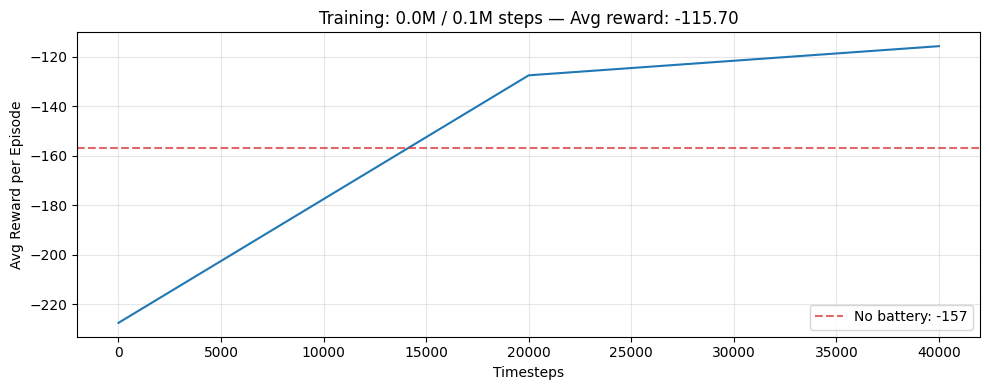

Training complete!


In [8]:
from stable_baselines3 import SAC

SAC_TIMESTEPS = int(5e4)

sac_train_env = make_vec_env(make_train_env, n_envs=4)
sac_model = SAC("MlpPolicy", sac_train_env, verbose=0)

sac_callback = LiveEvalCallback(
    eval_env=eval_env,
    eval_freq=20_000,
    baseline_cost=baseline_cost,
)

print(f"Training SAC for {SAC_TIMESTEPS/1e3:.0f}k steps...")
sac_model.learn(total_timesteps=SAC_TIMESTEPS, callback=sac_callback)
print("Training complete!")

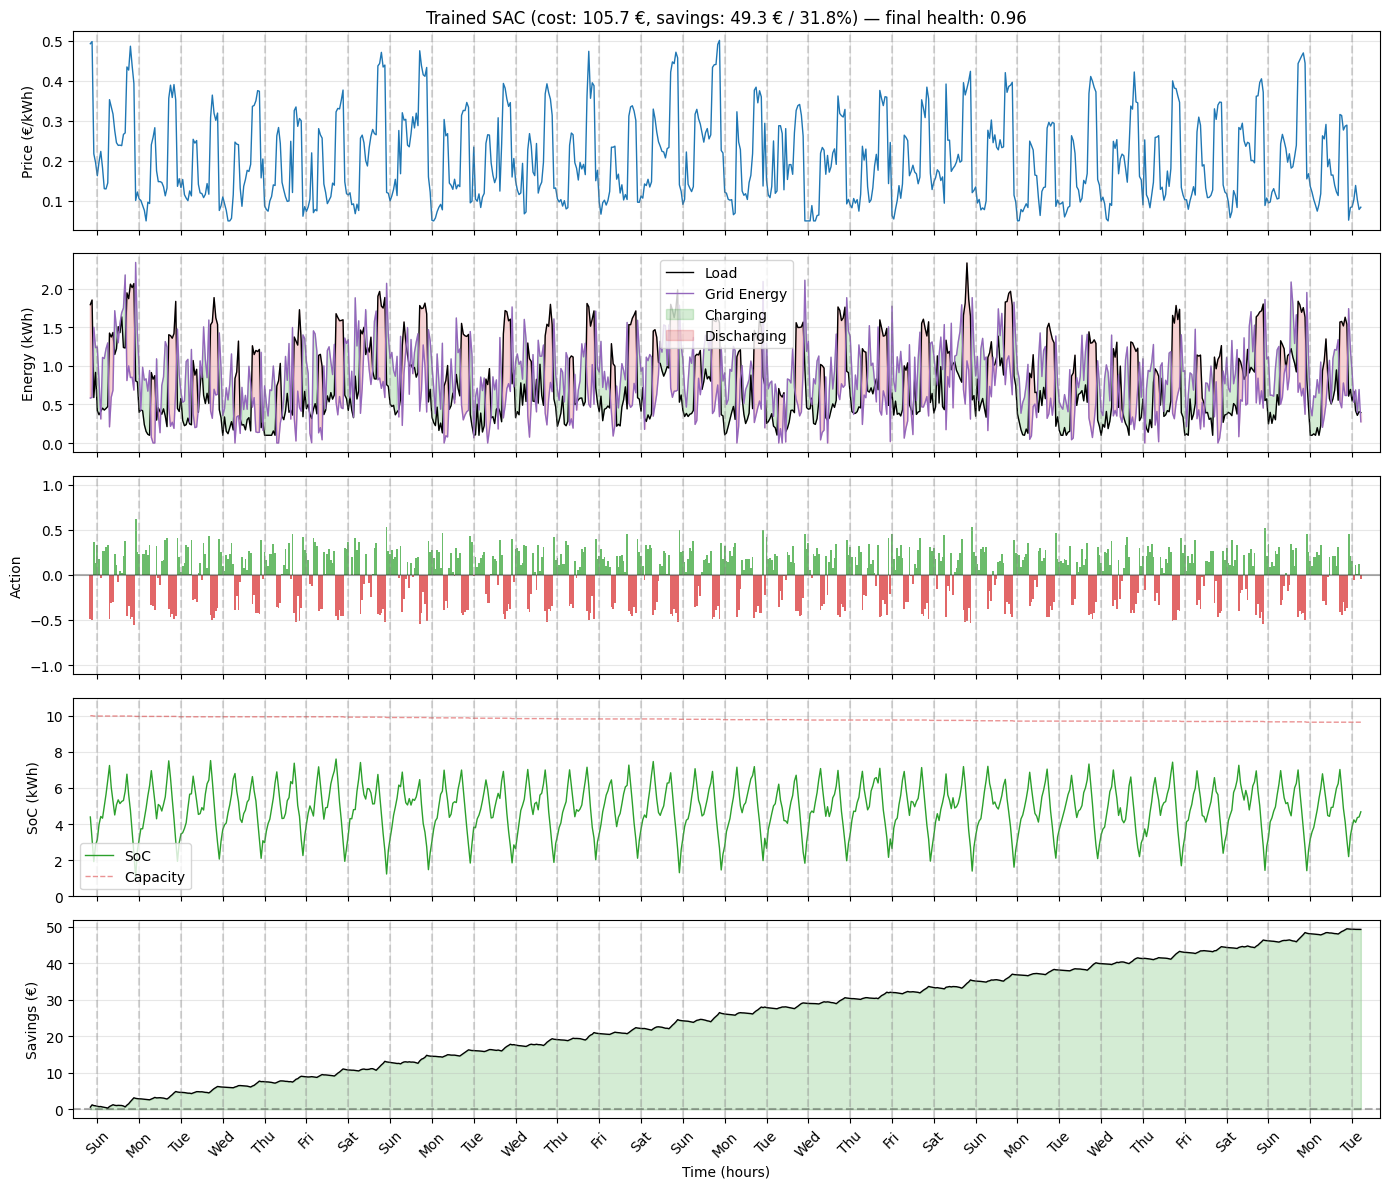

In [9]:
sac_policy = lambda obs: sac_model.predict(obs, deterministic=True)[0]
data_sac, reward_sac = run_episode(eval_env, policy=sac_policy, seed=42)
cost_sac = compute_energy_cost(data_sac)
no_battery_cost_sac = float(np.sum(np.array(data_sac["price"]) * np.array(data_sac["load"])))
savings_sac = no_battery_cost_sac - cost_sac

fig = plot_episode(data_sac, f"Trained SAC (cost: {cost_sac:.1f} \u20ac, savings: {savings_sac:.1f} \u20ac / {100*savings_sac/no_battery_cost_sac:.1f}%) — final health: {data_sac['health'][-1]:.2f}", xlim=(-10, EPISODE_LENGTH + 10))
plt.show()

## 6. Final Comparison

Now the comparison includes **final health**.

In [10]:
policies = {
    "Heuristic":    make_heuristic_policy(eval_env),
    "MPC (H=4)":    make_mpc_policy(eval_env, horizon=4),
    "LP (optimal)":  make_lp_policy(eval_env),
    "PPO":          lambda obs: model.predict(obs, deterministic=True)[0],
    "SAC":          lambda obs: sac_model.predict(obs, deterministic=True)[0],
}

first_episode_in_split, last_episode_in_split = eval_env._available_episodes
baseline_cost = np.mean(np.sum(eval_env.prices[first_episode_in_split:last_episode_in_split] * eval_env.loads[first_episode_in_split:last_episode_in_split], axis=1))

results = {}
for name, policy in policies.items():
    episode_costs = []
    episode_healths = []
    for seed in range(10):
        data, reward = run_episode(eval_env, policy=policy, seed=seed)
        energy_cost = compute_energy_cost(data)
        episode_costs.append(energy_cost)
        episode_healths.append(data["health"][-1])
    results[name] = {
        "cost": np.mean(episode_costs),
        "std": np.std(episode_costs),
        "health": np.mean(episode_healths),
    }

print(f"Baseline cost (no battery): {baseline_cost:.2f} \u20ac")
print()
print("Final Comparison (10 eval episodes)")
print("=" * 78)
print(f"{'Policy':<18} {'Avg Cost (\u20ac)':>15} {'Savings (\u20ac)':>15} {'Savings (%)':>12} {'Final Health':>14}")
print("-" * 78)
for name, r in results.items():
    savings = baseline_cost - r["cost"]
    pct = 100 * savings / baseline_cost if baseline_cost > 0 else 0
    print(f"{name:<18} {r['cost']:>11.1f} \u00b1 {r['std']:.1f} {savings:>+11.1f} {pct:>+11.1f}% {r['health']:>13.2f}")

Baseline cost (no battery): 156.78 €

Final Comparison (10 eval episodes)
Policy                Avg Cost (€)     Savings (€)  Savings (%)   Final Health
------------------------------------------------------------------------------
Heuristic                145.8 ± 5.2       +11.0        +7.0%          0.30
MPC (H=4)                118.0 ± 4.3       +38.8       +24.7%          0.30
LP (optimal)             106.6 ± 4.4       +50.2       +32.0%          0.30
PPO                      108.4 ± 4.2       +48.4       +30.9%          0.94
SAC                      109.0 ± 4.5       +47.7       +30.5%          0.96


**Key takeaways:**

- RL (PPO/SAC) learns to **balance** cost and health, achieving good savings while keeping the battery in much better condition.

**Experiments to try:**
- Change `health_weight` in `battery_env.py` — higher values make the agent more conservative, lower values more aggressive. How does this trade-off look?
- Try different `damage_rate` values — how does the severity of degradation affect the optimal strategy?

## 8. Discussion: When Does RL Actually Make Sense?

Looking at the results above, LP achieves low electricity cost but drives battery health to 0.30 (the minimum). PPO saves slightly more money and also preserves 85% of battery health. SAC is even more conservative, keeping health at 94%. 

But let's be honest about what happened here: **we designed the degradation model ourselves**. We know exactly when damage occurs (above 70% charge rate, SoC outside 20%–80%) and how much it costs (damage_rate = 0.002 per event, health_weight = 100 in the reward). So could we just tell LP about these rules too?

### Could we fix LP?

In principle, yes. The degradation rules introduce threshold-based, non-linear constraints. To encode this in LP, we'd need to reformulate the problem as a Mixed-Integer Linear Program (MILP), adding binary variables for each threshold condition at each timestep. This is technically possible, but MILPs are NP-hard, so solving them becomes dramatically slower as the problem grows. And this is still a simple degradation model. Real battery chemistry involves temperature dependence, cycle depth effects, calendar aging, and interactions between these factors that are difficult to capture in closed-form constraints.

### What does RL actually need?

The key insight is about what kind of model each approach requires. Classical optimization (LP, MILP) needs the dynamics translated into **mathematical equations** that the solver can reason about analytically. RL needs something weaker: a **simulator** (or real environment) that it can interact with, plus a **reward signal that captures what you care about**.

The reward signal is worth thinking about carefully. In our case, `reward = -grid_cost - health_weight * health_damage` tells the agent to minimize cost while preserving health, but it says nothing about *how* degradation works. The agent discovers the thresholds and safe operating zones through trial and error. This is a weaker requirement than having an analytical model: you need to know *what you want* (low cost, good health) but not necessarily *why* the system behaves as it does.

That said, this advantage is only real when the dynamics are genuinely hard to model analytically. In our workshop example, the degradation model is simple enough that MILP would work fine. The potential argument for RL is about **scaling to complexity**, not about this toy problem.

### Where does this actually work in practice?

There are domains where building a simulator is significantly easier than deriving optimization equations.

**Robotics** is a good example. A physics engine like MuJoCo or Isaac Gym can simulate rigid body dynamics, contact forces, and motor responses. These simulators are built from general physical principles, and RL agents trained in simulation have transferred to real robots for tasks like dexterous manipulation and locomotion (though this is still mainly ongoing research). Simulations can represent dynamics that are difficult to encode in differentiable optimization formulations.

**Data center cooling** is another case where RL has proven its value. DeepMind deployed an RL system at commercial cooling energy, saving around 10% of energy: https://arxiv.org/pdf/2211.07357

### Why is MPC still the industry standard?

Despite these success stories, Model Predictive Control (MPC) remains far more common in industrial applications than RL. There are practical reasons for this. MPC provides interpretability: operators can inspect the optimization and understand why a particular decision was made, which matters when something goes wrong. MPC offers safety guarantees through explicit constraints, ensuring the system never enters dangerous states. MPC requires no training phase and works from day one with a reasonable model. 

For battery storage specifically, MPC with a good forecast model is hard to beat in practice. 

### So when does RL win?

RL becomes compelling when the problem has dynamics that are too complex to formulate as optimization constraints but where a simulator (or the real system) is available for training. It also helps when the objective is multi-dimensional, as we saw here with the cost-health tradeoff, because reward shaping lets you express complex preferences without translating them into constraints. And RL scales naturally to high-dimensional state and action spaces where classical solvers struggle.

The most promising direction may be combining both: using MPC for safe, interpretable baseline control while letting RL handle the aspects that are hardest to model explicitly. This is an active area of research, and the right choice depends heavily on the specific application, the available models, and the tolerance for risk.